# Hierarchical Clustering

Yasir Ahmad  
22MIA1064

## Content
This data set contains statistics, in arrests per 100,000 residents
for assault, murder, and rape in each of the 50 US states in 1973.
Also given is the percent of the population living in urban areas.This is a systematic approach for identifying and analyzing patterns and trends in crime using USArrest dataset. 

## Import the Desired Libraries:

In [1]:
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

sns.set()
%matplotlib inline

In [3]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [4]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

## Reading and Understanding the Data

In [5]:
crime = pd.read_csv("/kaggle/input/violent-crime-rates-by-us-state/US_violent_crime.csv")

In [6]:
#peeking at the dataset

crime.head(5)

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


### Our dataset consists of crime rates for Murder, Assault, UrbanPop and Rape

In [7]:
# Let's see how many rows and columns we got!

crime.shape

(50, 5)

In [8]:
#Let's see some facts here

crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     object 
 1   Murder      50 non-null     float64
 2   Assault     50 non-null     int64  
 3   UrbanPop    50 non-null     int64  
 4   Rape        50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


### We have 50 rows and 5 columns.

In [9]:
# Let's get some statistics summary

crime.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


### Let's check for missing values.

In [10]:
crime.isnull().sum()

Unnamed: 0    0
Murder        0
Assault       0
UrbanPop      0
Rape          0
dtype: int64

### We have no missing values!

In [11]:
# Renaming the column as Unnmaed doesn't make sense.

crime = crime.rename(columns={'Unnamed: 0':'State'})

In [12]:
crime.head()

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [13]:
data = crime.iloc[:,1:].values

In [14]:
data

array([[ 13.2, 236. ,  58. ,  21.2],
       [ 10. , 263. ,  48. ,  44.5],
       [  8.1, 294. ,  80. ,  31. ],
       [  8.8, 190. ,  50. ,  19.5],
       [  9. , 276. ,  91. ,  40.6],
       [  7.9, 204. ,  78. ,  38.7],
       [  3.3, 110. ,  77. ,  11.1],
       [  5.9, 238. ,  72. ,  15.8],
       [ 15.4, 335. ,  80. ,  31.9],
       [ 17.4, 211. ,  60. ,  25.8],
       [  5.3,  46. ,  83. ,  20.2],
       [  2.6, 120. ,  54. ,  14.2],
       [ 10.4, 249. ,  83. ,  24. ],
       [  7.2, 113. ,  65. ,  21. ],
       [  2.2,  56. ,  57. ,  11.3],
       [  6. , 115. ,  66. ,  18. ],
       [  9.7, 109. ,  52. ,  16.3],
       [ 15.4, 249. ,  66. ,  22.2],
       [  2.1,  83. ,  51. ,   7.8],
       [ 11.3, 300. ,  67. ,  27.8],
       [  4.4, 149. ,  85. ,  16.3],
       [ 12.1, 255. ,  74. ,  35.1],
       [  2.7,  72. ,  66. ,  14.9],
       [ 16.1, 259. ,  44. ,  17.1],
       [  9. , 178. ,  70. ,  28.2],
       [  6. , 109. ,  53. ,  16.4],
       [  4.3, 102. ,  62. ,  16.5],
 

In [15]:
scaled_data = scaler.fit_transform(data)

# Types of Linkages:

## 1) Single Leakage:

The distance between 2 clusters is defined as the shortest distance between points in the two clusters

#### The hierarchy class has a dendrogram method which takes the value returned by the linkage method of the same class. The linkage method takes the dataset and the method to minimize distances as parameters.

### Euclidean

Text(0, 0.5, 'Euclidean distances')

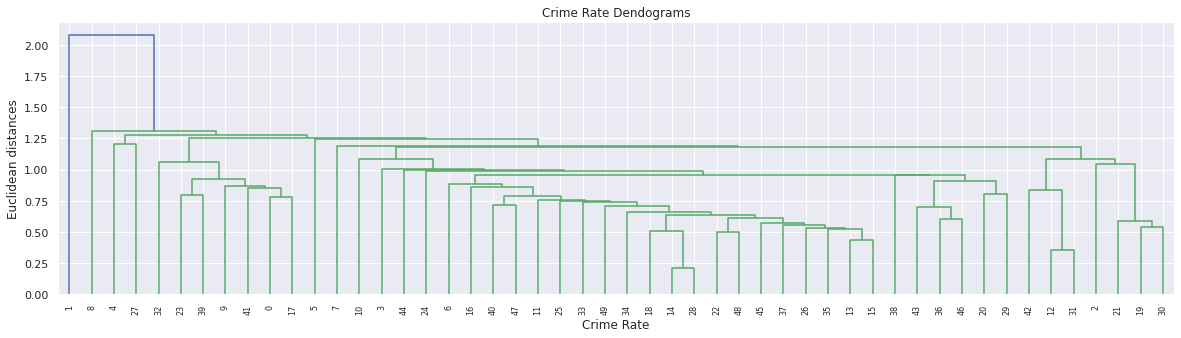

In [16]:
plt.figure(figsize=(20,5))
plt.title("Crime Rate Dendograms")
dend = sch.dendrogram(sch.linkage(scaled_data, method='single'))
plt.xlabel('Crime Rate')
plt.ylabel('Euclidean distances')

### Manhattan

Text(0, 0.5, 'Manhattan distances')

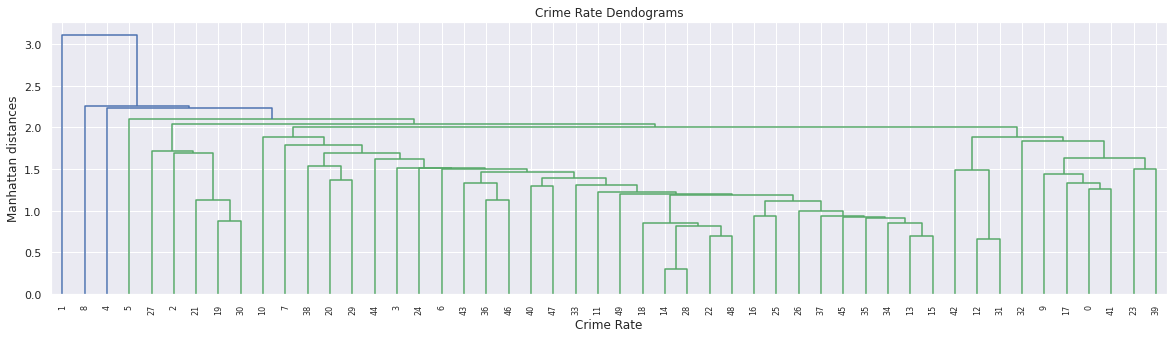

In [17]:
plt.figure(figsize=(20,5))
plt.title("Crime Rate Dendograms")
dend = sch.dendrogram(sch.linkage(scaled_data, method='single',metric='cityblock'))
plt.xlabel('Crime Rate')
plt.ylabel('Manhattan distances')

### Maximum Norm Distance

Text(0, 0.5, 'Maximum norm distances')

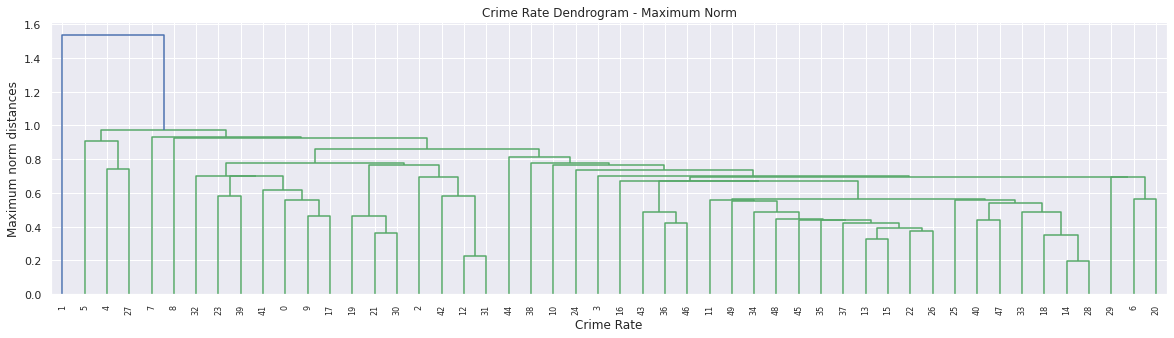

In [18]:
plt.figure(figsize=(20, 5))
plt.title("Crime Rate Dendrogram - Maximum Norm")
dend = sch.dendrogram(sch.linkage(scaled_data, method='single', metric='chebyshev'))
plt.xlabel('Crime Rate')
plt.ylabel('Maximum norm distances')


### Mahalanobis distance

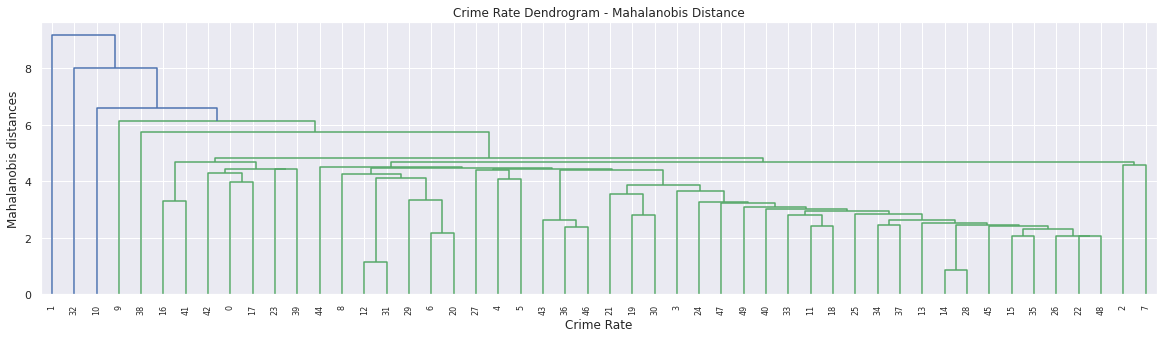

In [19]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform
import numpy as np

# Compute the covariance matrix
cov_matrix = np.cov(scaled_data, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Define a custom Mahalanobis distance function
def mahalanobis(u, v, VI):
    delta = u - v
    return np.sqrt(np.dot(np.dot(delta, VI), delta.T))

# Compute the distance matrix
mahalanobis_distances = pdist(scaled_data, metric=mahalanobis, VI=inv_cov_matrix)

# Perform hierarchical clustering
plt.figure(figsize=(20, 5))
plt.title("Crime Rate Dendrogram - Mahalanobis Distance")
dend = sch.dendrogram(sch.linkage(squareform(mahalanobis_distances), method='single'))
plt.xlabel('Crime Rate')
plt.ylabel('Mahalanobis distances')
plt.show()


### Inner Product space

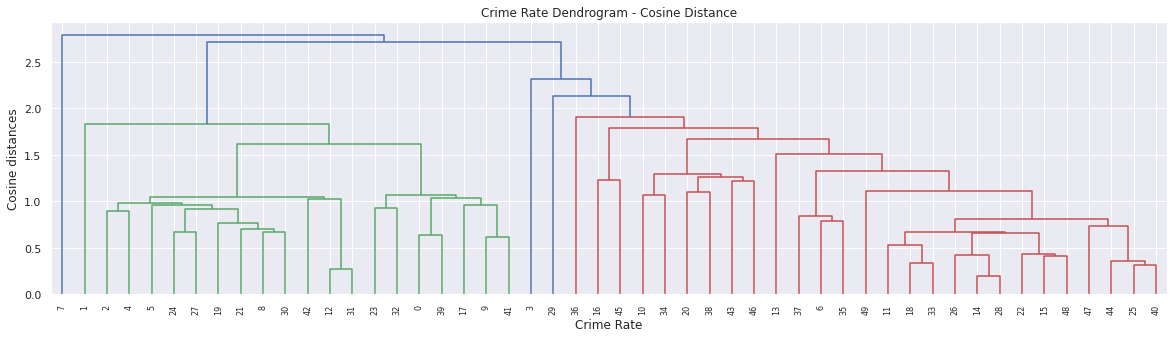

In [20]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

# Define a custom cosine distance function
def cosine_distance(u, v):
    return 1 - np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Compute the distance matrix
cosine_distances = pdist(scaled_data, metric=cosine_distance)

# Perform hierarchical clustering
plt.figure(figsize=(20, 5))
plt.title("Crime Rate Dendrogram - Cosine Distance")
dend = sch.dendrogram(sch.linkage(squareform(cosine_distances), method='single'))
plt.xlabel('Crime Rate')
plt.ylabel('Cosine distances')
plt.show()


## 2) Complete Linkage:

The distance between 2 clusters is defined as the maximum distance between any 2 points in the clusters

### Euclidean Distance

Text(0, 0.5, 'Euclidean distances')

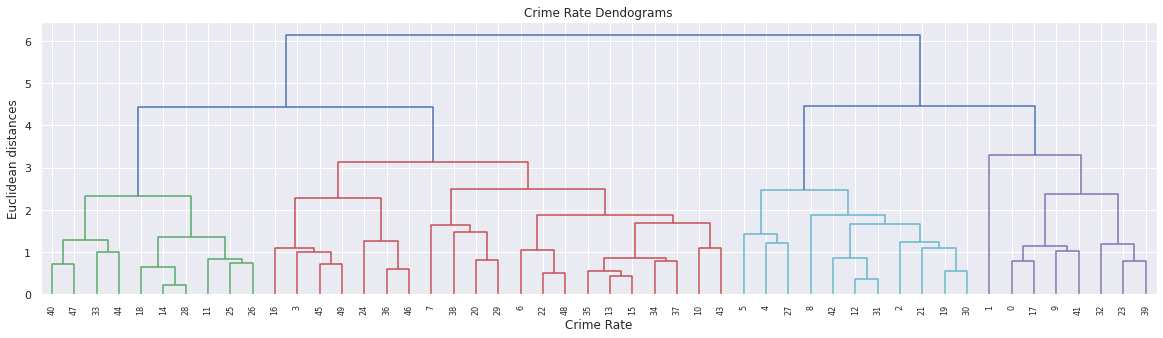

In [21]:
plt.figure(figsize=(20,5))
plt.title("Crime Rate Dendograms")
dend = sch.dendrogram(sch.linkage(scaled_data, method='complete'))
plt.xlabel('Crime Rate')
plt.ylabel('Euclidean distances')

### Manhattan distance

Text(0, 0.5, 'Manhattan distances')

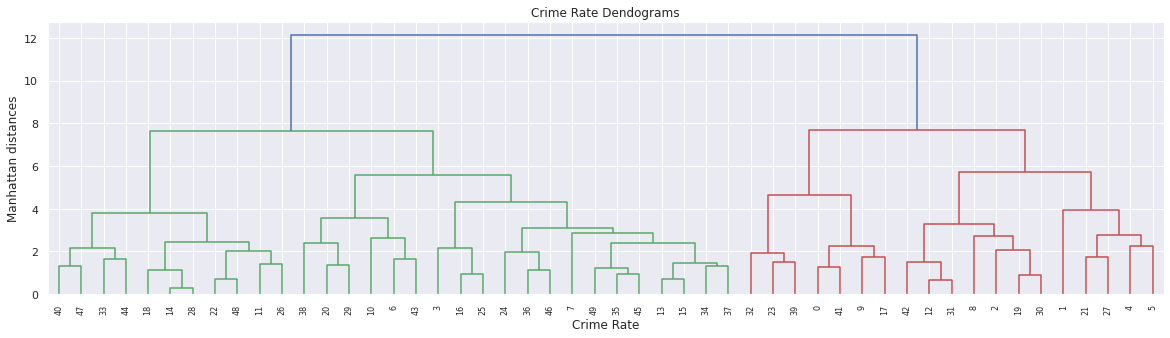

In [22]:
plt.figure(figsize=(20,5))
plt.title("Crime Rate Dendograms")
dend = sch.dendrogram(sch.linkage(scaled_data, method='complete',metric='cityblock'))
plt.xlabel('Crime Rate')
plt.ylabel('Manhattan distances')

### Maximum Norm distance

Text(0, 0.5, 'Maximum norm distances')

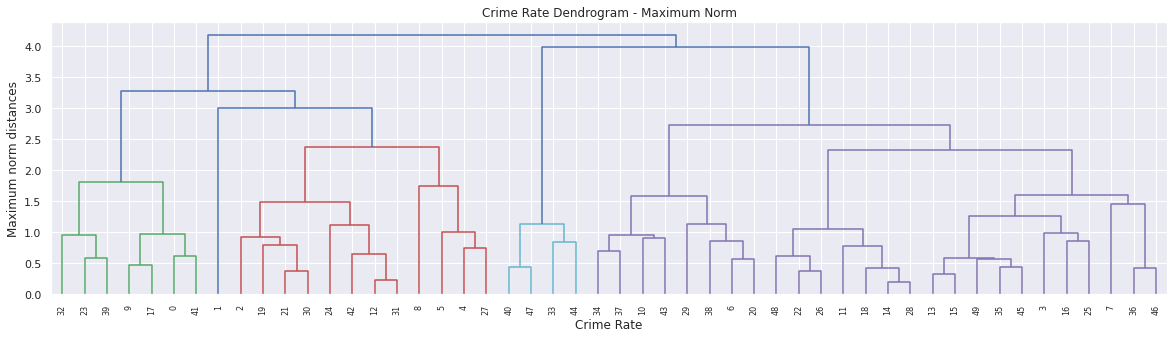

In [23]:
plt.figure(figsize=(20, 5))
plt.title("Crime Rate Dendrogram - Maximum Norm")
dend = sch.dendrogram(sch.linkage(scaled_data, method='complete', metric='chebyshev'))
plt.xlabel('Crime Rate')
plt.ylabel('Maximum norm distances')


### Mahalanobis distance

Text(0, 0.5, 'Mahalanobis distances')

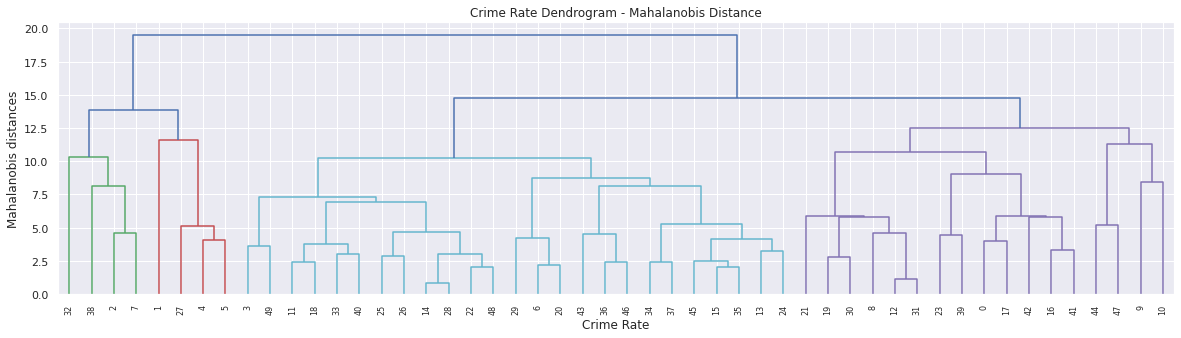

In [24]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform
import numpy as np

# Compute the covariance matrix
cov_matrix = np.cov(scaled_data, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Define a custom Mahalanobis distance function
def mahalanobis(u, v, VI):
    delta = u - v
    return np.sqrt(np.dot(np.dot(delta, VI), delta.T))

# Compute the distance matrix
mahalanobis_distances = pdist(scaled_data, metric=mahalanobis, VI=inv_cov_matrix)

# Perform hierarchical clustering
plt.figure(figsize=(20, 5))
plt.title("Crime Rate Dendrogram - Mahalanobis Distance")
dend = sch.dendrogram(sch.linkage(squareform(mahalanobis_distances), method='complete'))
plt.xlabel('Crime Rate')
plt.ylabel('Mahalanobis distances')


### Inner product

Text(0, 0.5, 'Cosine distances')

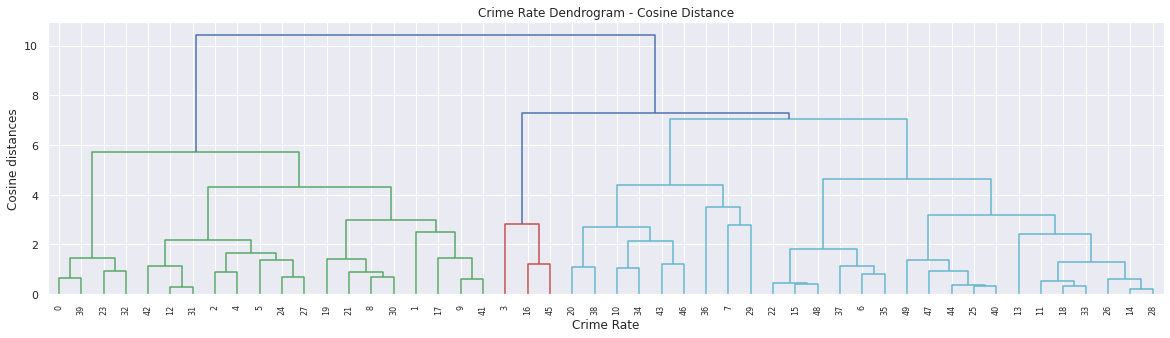

In [25]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

# Define a custom cosine distance function
def cosine_distance(u, v):
    return 1 - np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Compute the distance matrix
cosine_distances = pdist(scaled_data, metric=cosine_distance)

# Perform hierarchical clustering
plt.figure(figsize=(20, 5))
plt.title("Crime Rate Dendrogram - Cosine Distance")
dend = sch.dendrogram(sch.linkage(squareform(cosine_distances), method='complete'))
plt.xlabel('Crime Rate')
plt.ylabel('Cosine distances')


## 3) Ward Linkage

#### The single linkage type will produce dendrograms which are not structured properly, whereas complete or average linkage will produce clusters which have a proper tree-like structure.

### Euclidean

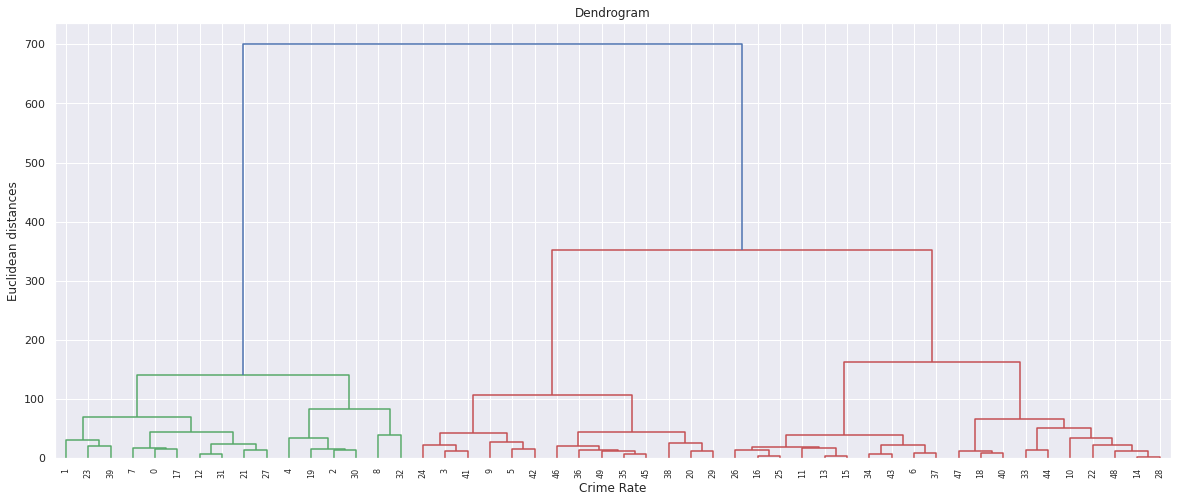

In [26]:
# With Ward method
plt.figure(figsize=(20,8))
dendrogram = sch.dendrogram(sch.linkage(data, method  = "ward"))
plt.title('Dendrogram')
plt.xlabel('Crime Rate')
plt.ylabel('Euclidean distances')
plt.show()

## Optimal K

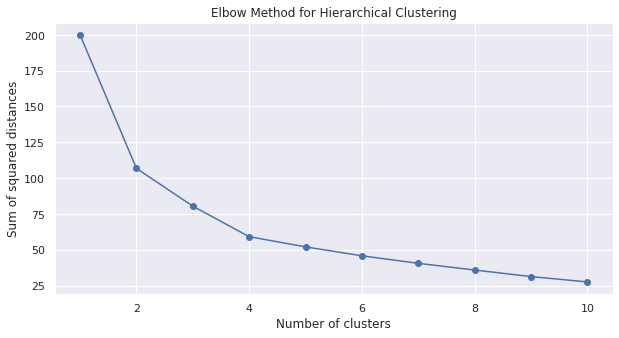

In [27]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming scaled_data is your dataset
scaled_data = StandardScaler().fit_transform(scaled_data)

# Perform hierarchical clustering
linked = sch.linkage(scaled_data, method='ward')

# Evaluate inertia for different numbers of clusters
inertia = []
range_n_clusters = range(1, 11)  # Example range of clusters

for n_clusters in range_n_clusters:
    clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = clustering.fit_predict(scaled_data)
    # Calculate inertia (sum of squared distances)
    centers = np.array([scaled_data[cluster_labels == i].mean(axis=0) for i in range(n_clusters)])
    inertia.append(np.sum([np.sum((scaled_data[cluster_labels == i] - centers[i]) ** 2) for i in range(n_clusters)]))

# Plot inertia values
plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method for Hierarchical Clustering')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared distances')
plt.show()


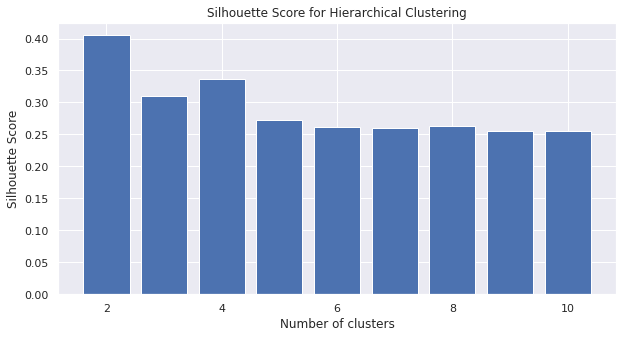

In [28]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming scaled_data is your dataset
scaled_data = StandardScaler().fit_transform(scaled_data)

# Perform hierarchical clustering
linked = sch.linkage(scaled_data, method='ward')

# Evaluate Silhouette scores for different numbers of clusters
silhouette_scores = []
range_n_clusters = range(2, 11)  # Example range of clusters

for n_clusters in range_n_clusters:
    cluster_labels = sch.fcluster(linked, n_clusters, criterion='maxclust')
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette scores
plt.figure(figsize=(10, 5))
plt.bar(range_n_clusters, silhouette_scores)
plt.title('Silhouette Score for Hierarchical Clustering')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


### taking 4 as optimal K

In [29]:
# Fit the Agglomerative Clustering
 
AC = AgglomerativeClustering(n_clusters = 4, affinity = 'euclidean', linkage ='ward')

**Ward** method is actually a method that tries to minimize the variance within each cluster. In K-means when we were trying to minimize the wcss to plot our elbow method chart, here it’s almost the same the only difference is that instead of minimizing wcss we are minimizing the within-cluster variants. That is the variance within each cluster.

In [30]:
# Fit and predict to have the cluster labels.
y_pred =AC.fit_predict(data)
y_pred

array([0, 0, 0, 2, 0, 2, 3, 0, 0, 2, 1, 3, 0, 3, 1, 3, 3, 0, 1, 0, 2, 0,
       1, 0, 2, 3, 3, 0, 1, 2, 0, 0, 0, 1, 3, 2, 2, 3, 2, 0, 1, 2, 2, 3,
       1, 2, 2, 1, 1, 2])

In [31]:
silhouette_avg = silhouette_score(scaled_data, y_pred)
silhouette_avg

0.09018767713149535

In [32]:
# Fetch the cluster labels
crime['cluster labels']= y_pred

In [33]:
# Let's see which State falls in which cluster
crime[['State','cluster labels']]

,State,cluster labels
0,Alabama,0
1,Alaska,0
2,Arizona,0
3,Arkansas,2
4,California,0
5,Colorado,2
6,Connecticut,3
7,Delaware,0
8,Florida,0
9,Georgia,2


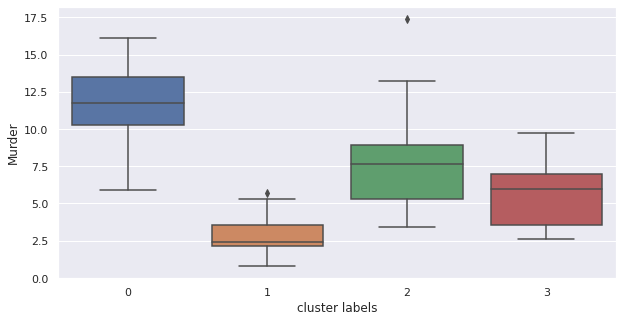

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cluster labels', y='Murder', data=crime)

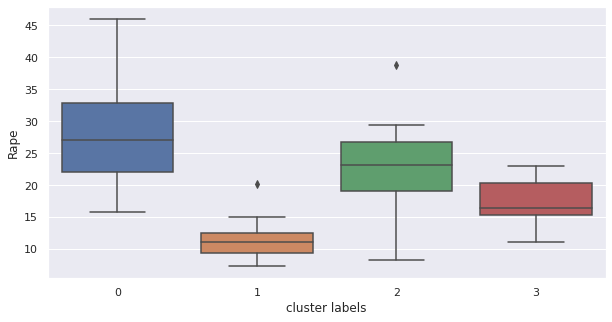

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cluster labels', y='Rape', data=crime)

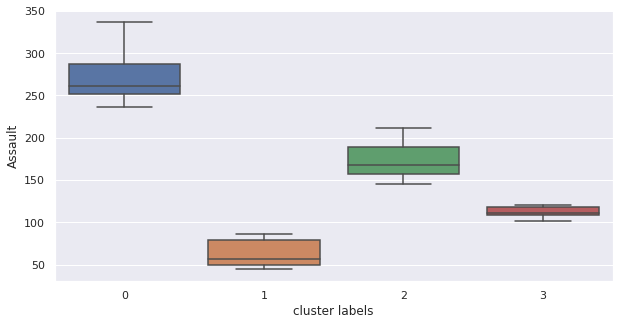

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cluster labels', y='Assault', data=crime)

# Summary of Agnes

## **Observations**:

* The Cities in Cluster-0 seems to have higher crime rates and can be regarded as **Danger-Zone.**
* The Cities in the Cluster-1 seems to be **Safe-Zone** where there are relativley less Murders,Assaults and Rapes.
* The Cities in Cluster-2 seems to have higher crime rates and can be regarded as **Risk-Zone.**
* The Cities in Cluster-3 seems to have less crime rates when compared to other zones and can be called as **Moderate-Zone**


In [37]:
Danger_Zone= crime.groupby('cluster labels')['State'].unique()[0]
Danger_Zone

array(['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware',
       'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan',
       'Mississippi', 'Nevada', 'New Mexico', 'New York',
       'North Carolina', 'South Carolina'], dtype=object)

In [38]:
Safe_Zone= crime.groupby('cluster labels')['State'].unique()[1]
Safe_Zone

array(['Hawaii', 'Iowa', 'Maine', 'Minnesota', 'New Hampshire',
       'North Dakota', 'South Dakota', 'Vermont', 'West Virginia',
       'Wisconsin'], dtype=object)

In [39]:
Risk_Zone= crime.groupby('cluster labels')['State'].unique()[2]
Risk_Zone

array(['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri',
       'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee',
       'Texas', 'Virginia', 'Washington', 'Wyoming'], dtype=object)

In [40]:
Moderate_Zone= crime.groupby('cluster labels')['State'].unique()[3]
Moderate_Zone

array(['Connecticut', 'Idaho', 'Indiana', 'Kansas', 'Kentucky', 'Montana',
       'Nebraska', 'Ohio', 'Pennsylvania', 'Utah'], dtype=object)

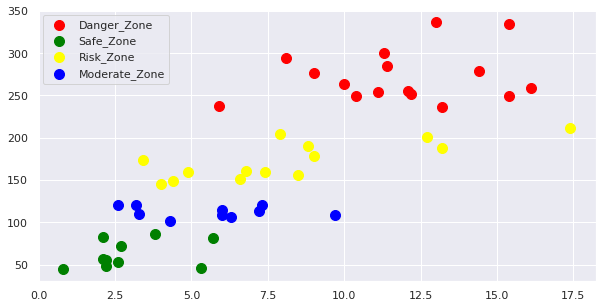

In [41]:
plt.figure(figsize=(10,5))
plt.scatter(data[y_pred==0, 0], data[y_pred==0, 1], s=100, c='red', label ='Danger_Zone')
plt.scatter(data[y_pred==1, 0], data[y_pred==1, 1], s=100, c='green', label ='Safe_Zone')
plt.scatter(data[y_pred==2, 0], data[y_pred==2, 1], s=100, c='yellow', label ='Risk_Zone')
plt.scatter(data[y_pred==3, 0], data[y_pred==3, 1], s=100, c='blue', label ='Moderate_Zone')
plt.legend()
plt.show()

In [42]:
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px

df = pd.DataFrame(crime)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=df['Murder'],
    y=df['Assault'],
    z=df['Rape'],
    mode='markers',
    marker=dict(
        size=10,
        color=df['cluster labels'],  # Set color to cluster labels
        colorscale='Viridis',        # Choose a colorscale
        opacity=0.8
    )
)])

# Add labels to axes
fig.update_layout(
    scene=dict(
        xaxis_title='Murder',
        yaxis_title='Assault',
        zaxis_title='Rape'
    ),
    title='3D Crime Data Plot'
)

# Show plot
fig.show()


# Diana

DIANA is also known as DIvisie ANAlysis clustering algorithm. It is the top-down approach form of hierarchical clustering where all data points are initially assigned a single cluster.

In [43]:
data

array([[ 13.2, 236. ,  58. ,  21.2],
       [ 10. , 263. ,  48. ,  44.5],
       [  8.1, 294. ,  80. ,  31. ],
       [  8.8, 190. ,  50. ,  19.5],
       [  9. , 276. ,  91. ,  40.6],
       [  7.9, 204. ,  78. ,  38.7],
       [  3.3, 110. ,  77. ,  11.1],
       [  5.9, 238. ,  72. ,  15.8],
       [ 15.4, 335. ,  80. ,  31.9],
       [ 17.4, 211. ,  60. ,  25.8],
       [  5.3,  46. ,  83. ,  20.2],
       [  2.6, 120. ,  54. ,  14.2],
       [ 10.4, 249. ,  83. ,  24. ],
       [  7.2, 113. ,  65. ,  21. ],
       [  2.2,  56. ,  57. ,  11.3],
       [  6. , 115. ,  66. ,  18. ],
       [  9.7, 109. ,  52. ,  16.3],
       [ 15.4, 249. ,  66. ,  22.2],
       [  2.1,  83. ,  51. ,   7.8],
       [ 11.3, 300. ,  67. ,  27.8],
       [  4.4, 149. ,  85. ,  16.3],
       [ 12.1, 255. ,  74. ,  35.1],
       [  2.7,  72. ,  66. ,  14.9],
       [ 16.1, 259. ,  44. ,  17.1],
       [  9. , 178. ,  70. ,  28.2],
       [  6. , 109. ,  53. ,  16.4],
       [  4.3, 102. ,  62. ,  16.5],
 

## Algorithm

In [44]:
import numpy as np
import pandas as pd
import pickle
from scipy.spatial.distance import pdist, squareform

# Function to calculate the distance (similarity) matrix using Euclidean distance
def DistanceMatrix(data):
    '''
    Argument
    ---------
    data - pandas DataFrame containing numerical features

    Returns
    ---------
    similarity_matrix - 2D numpy array of distances between data points
    '''
    # Using Euclidean distance to compute the distance matrix
    dist_matrix = squareform(pdist(data, metric='euclidean'))

    return dist_matrix

# Main class that computes the clusters using the DIANA algorithm
class DianaClustering:
    def __init__(self, data):
        '''
        Constructor of the class, takes the main data frame as input
        '''
        self.data = data
        self.n_samples, self.n_features = data.shape

    def fit(self, n_clusters):
        '''
        This method uses the Divisive Analysis (DIANA) algorithm to perform clustering

        Arguments
        ---------
        n_clusters - integer
                     number of clusters we want

        Returns
        ---------
        cluster_labels - numpy array
                         an array where cluster number of each sample is stored
        '''
        similarity_matrix = DistanceMatrix(self.data)  # similarity matrix of the data
        clusters = [list(range(self.n_samples))]  # initially, the entire dataset is one cluster

        while len(clusters) < n_clusters:
            # Find the cluster with the largest diameter (distance)
            c_diameters = [np.max(similarity_matrix[cluster][:, cluster]) for cluster in clusters]
            max_cluster_idx = np.argmax(c_diameters)

            # Find the sample that has the maximum average dissimilarity in the cluster
            max_diff_idx = np.argmax(np.mean(similarity_matrix[clusters[max_cluster_idx]][:, clusters[max_cluster_idx]], axis=1))
            splinters = [clusters[max_cluster_idx][max_diff_idx]]  # start a new splinter group

            remaining_cluster = clusters[max_cluster_idx]
            del remaining_cluster[max_diff_idx]

            while True:
                split = False
                for j in range(len(remaining_cluster))[::-1]:
                    splinter_distances = similarity_matrix[remaining_cluster[j], splinters]
                    cluster_distances = similarity_matrix[remaining_cluster[j], np.delete(remaining_cluster, j, axis=0)]

                    if np.mean(splinter_distances) <= np.mean(cluster_distances):
                        splinters.append(remaining_cluster[j])
                        del remaining_cluster[j]
                        split = True
                        break

                if not split:
                    break

            del clusters[max_cluster_idx]
            clusters.append(splinters)
            clusters.append(remaining_cluster)

        # Assign cluster labels
        cluster_labels = np.zeros(self.n_samples)
        for i, cluster in enumerate(clusters):
            cluster_labels[cluster] = i

        return cluster_labels


if __name__ == '__main__':
    """ # Load the dataset (adjust the file path as necessary)
    data = pd.read_csv('your_dataset.csv')  # Replace with your dataset file path

    # Assuming the dataset has 4 features, e.g., 'Feature1', 'Feature2', 'Feature3', 'Feature4'
    data = data[['Feature1', 'Feature2', 'Feature3', 'Feature4']]  # Keep only the 4 features
    """
    diana = DianaClustering(data)  # Applying the DIANA Clustering algorithm
    clusters = diana.fit(n_clusters=5)  # Number of clusters, e.g., 3 clusters
    print(clusters)


[0. 0. 4. 0. 4. 0. 2. 0. 3. 0. 1. 2. 0. 2. 1. 2. 2. 0. 1. 4. 2. 0. 1. 0.
 2. 2. 2. 0. 1. 2. 4. 0. 3. 1. 2. 2. 2. 2. 2. 4. 1. 0. 0. 2. 1. 2. 2. 1.
 1. 2.]


## Dendogram

### Logic

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Function for divisive clustering using KMeans
def divisive_clustering(data, k=2):
    clusters = [(0, data)]  # Start with one cluster
    splits = []
    cluster_counter = 1

    while clusters:
        idx, cluster_data = clusters.pop(0)
        if len(cluster_data) <= 1:  # Stop when the cluster has 1 point
            continue

        # Apply KMeans to split the cluster into 2
        kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(cluster_data)
        labels = kmeans.labels_

        left_cluster = cluster_data[labels == 0]
        right_cluster = cluster_data[labels == 1]

        # Only record splits where both clusters are non-empty
        if len(left_cluster) > 0 and len(right_cluster) > 0:
            # Append split (parent cluster id, left child, right child, size of parent cluster)
            splits.append((idx, cluster_counter, cluster_counter + 1, len(cluster_data)))

            # Add new clusters to the list
            clusters.append((cluster_counter, left_cluster))
            clusters.append((cluster_counter + 1, right_cluster))

            # Increment cluster counter
            cluster_counter += 2

    return splits

# Function to plot divisive dendrogram
def plot_divisive_dendrogram(splits, num_samples):
    fig, ax = plt.subplots()

    def draw_line(x1, y1, x2, y2):
        ax.plot([x1, x2], [y1, y2], 'k-')

    # Start positions for original samples
    cluster_positions = {i: (i, 0) for i in range(num_samples)}
    y_position = -1

    for split in splits:
        parent, left, right, parent_size = split
        parent_pos = cluster_positions[parent]
        left_pos = cluster_positions[left] = (parent_pos[0] - parent_size / 4, y_position)
        right_pos = cluster_positions[right] = (parent_pos[0] + parent_size / 4, y_position)

        # Draw vertical line from parent to children
        draw_line(parent_pos[0], parent_pos[1], parent_pos[0], y_position)
        # Draw horizontal line connecting children
        draw_line(left_pos[0], y_position, right_pos[0], y_position)

        y_position -= 1

    # Set plot limits and labels
    ax.set_ylim(y_position, 1)
    ax.set_xlim(-1, num_samples)
    ax.set_xticks(range(num_samples))
    ax.set_xlabel('Samples')
    ax.set_ylabel('Hierarchy Level')
    plt.title("Divisive Clustering Dendrogram")
    plt.gca().invert_yaxis()  # Invert
    plt.show()

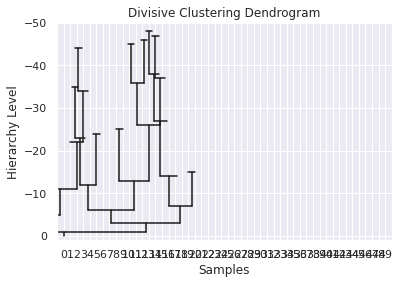

In [46]:
# prompt: do the divisive dendogram

# Perform divisive clustering
splits = divisive_clustering(data)

# Plot the divisive dendrogram
plot_divisive_dendrogram(splits, len(data))

## Optimal K

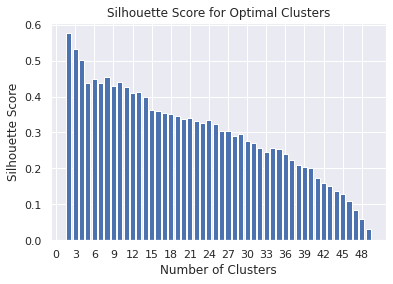

The optimal number of clusters is 2


In [47]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# Silhouette Score
silhouette_scores = []
for n in range(2, len(data)):
    clustering = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = clustering.fit_predict(data)
    silhouette_scores.append(silhouette_score(data, labels))

# Plot the Silhouette Score graph
plt.bar(range(2, len(data)), silhouette_scores)
plt.title('Silhouette Score for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.xticks(np.arange(0,50,3))
plt.ylabel('Silhouette Score')
plt.show()

# Find the optimal number of clusters based on the highest silhouette score
optimal_clusters = np.argmax(silhouette_scores) + 2
print(f'The optimal number of clusters is {optimal_clusters}')


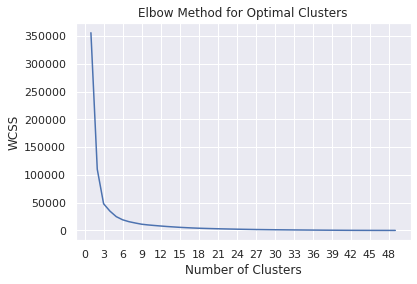

In [48]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Elbow Method using within-cluster sum of squares (WCSS)
def calculate_wcss(data):
    wcss = []
    for n in range(1, len(data)):
        clustering = AgglomerativeClustering(n_clusters=n, linkage='ward')
        labels = clustering.fit_predict(data)
        cluster_centers = [data[labels == i].mean(axis=0) for i in range(n)]
        wcss.append(sum(np.sum((data[labels == i] - cluster_centers[i]) ** 2) for i in range(n)))
    return wcss

wcss = calculate_wcss(data)

# Plot the Elbow Method graph
plt.plot(range(1, len(data)), wcss)
plt.title('Elbow Method for Optimal Clusters')
plt.xticks(np.arange(0, 50, 3))  
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


Optimal k = 3

In [49]:

if __name__ == '__main__':
    """ # Load the dataset (adjust the file path as necessary)
    data = pd.read_csv('your_dataset.csv')  # Replace with your dataset file path

    # Assuming the dataset has 4 features, e.g., 'Feature1', 'Feature2', 'Feature3', 'Feature4'
    data = data[['Feature1', 'Feature2', 'Feature3', 'Feature4']]  # Keep only the 4 features
    """
    diana = DianaClustering(data)  # Applying the DIANA Clustering algorithm
    clusters = diana.fit(n_clusters=3)  # Number of clusters, e.g., 3 clusters
    print(clusters)


[2. 2. 1. 2. 1. 2. 0. 2. 1. 2. 0. 0. 2. 0. 0. 0. 0. 2. 0. 1. 0. 2. 0. 2.
 0. 0. 0. 2. 0. 0. 1. 2. 1. 0. 0. 0. 0. 0. 0. 1. 0. 2. 2. 0. 0. 0. 0. 0.
 0. 0.]


# Visualization

### Dendogram

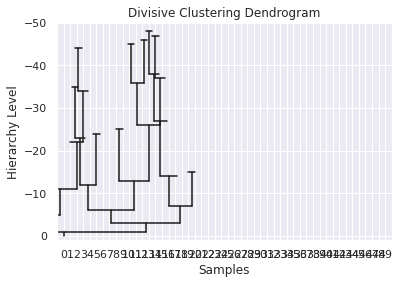

In [50]:
# prompt: do the divisive dendogram

# Perform divisive clustering
splits = divisive_clustering(data)

# Plot the divisive dendrogram
plot_divisive_dendrogram(splits, len(data))

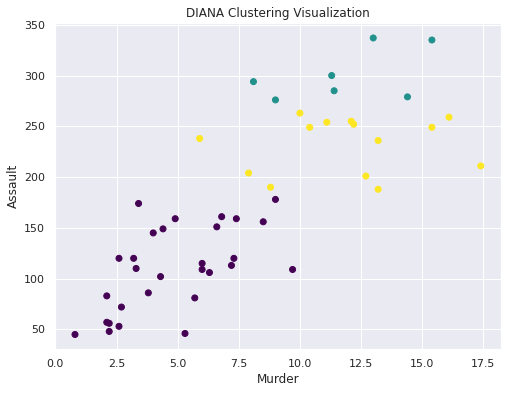

In [51]:
# prompt: visualise the clusters

import matplotlib.pyplot as plt

# Assuming 'data' and 'clusters' are defined from the previous code

# Select two features for visualization (e.g., 'Murder' and 'Assault')
x = crime['Murder'].values
y = crime['Assault'].values

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=clusters, cmap='viridis')
plt.xlabel('Murder')
plt.ylabel('Assault')
plt.title('DIANA Clustering Visualization')
plt.show()


In [52]:
# Fetch the cluster labels
crime['cluster labels']= clusters

In [53]:
crime[['State','cluster labels']]

,State,cluster labels
0,Alabama,2.0
1,Alaska,2.0
2,Arizona,1.0
3,Arkansas,2.0
4,California,1.0
5,Colorado,2.0
6,Connecticut,0.0
7,Delaware,2.0
8,Florida,1.0
9,Georgia,2.0


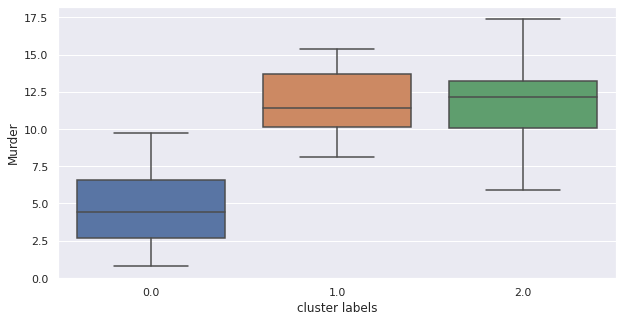

In [54]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cluster labels', y='Murder', data=crime)


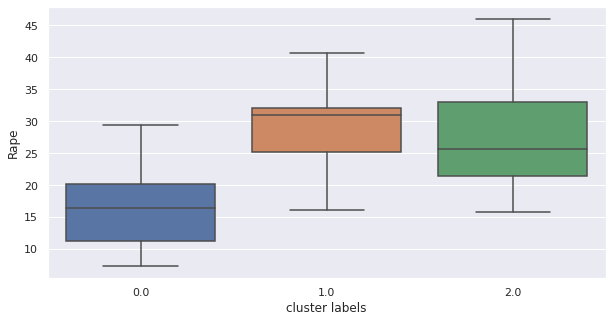

In [55]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cluster labels', y='Rape', data=crime)

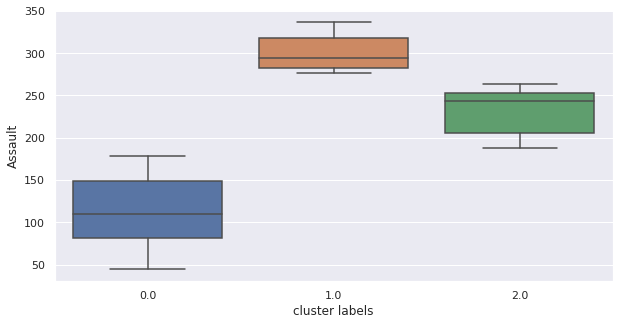

In [56]:
plt.figure(figsize=(10,5))
sns.boxplot(x='cluster labels', y='Assault', data=crime)

# Summary of Diana

In [57]:
Danger_Zone= crime.groupby('cluster labels')['State'].unique()[1]
Danger_Zone

array(['Arizona', 'California', 'Florida', 'Maryland', 'New Mexico',
       'North Carolina', 'South Carolina'], dtype=object)

In [58]:
Safe_Zone= crime.groupby('cluster labels')['State'].unique()[0]
Safe_Zone

array(['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas',
       'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Missouri',
       'Montana', 'Nebraska', 'New Hampshire', 'New Jersey',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia',
       'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'],
      dtype=object)

In [59]:
Moderate_Zone= crime.groupby('cluster labels')['State'].unique()[2]
Moderate_Zone

array(['Alabama', 'Alaska', 'Arkansas', 'Colorado', 'Delaware', 'Georgia',
       'Illinois', 'Louisiana', 'Michigan', 'Mississippi', 'Nevada',
       'New York', 'Tennessee', 'Texas'], dtype=object)

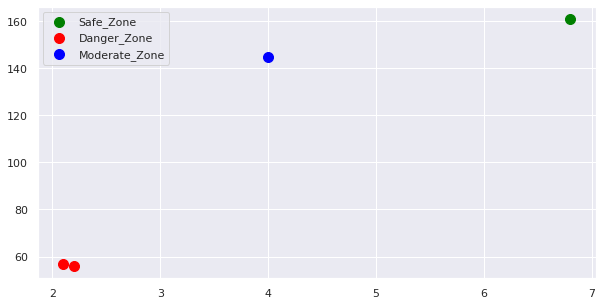

In [60]:
plt.figure(figsize=(10,5))
plt.scatter(data[labels==1, 0], data[labels==1, 1], s=100, c='green', label ='Safe_Zone')
plt.scatter(data[labels==0, 0], data[labels==0, 1], s=100, c='red', label ='Danger_Zone')
plt.scatter(data[labels==2, 0], data[labels==2, 1], s=100, c='blue', label ='Moderate_Zone')
plt.legend()
plt.show()

In [61]:
crime

,State,Murder,Assault,UrbanPop,Rape,cluster labels
0,Alabama,13.2,236,58,21.2,2.0
1,Alaska,10.0,263,48,44.5,2.0
2,Arizona,8.1,294,80,31.0,1.0
3,Arkansas,8.8,190,50,19.5,2.0
4,California,9.0,276,91,40.6,1.0
5,Colorado,7.9,204,78,38.7,2.0
6,Connecticut,3.3,110,77,11.1,0.0
7,Delaware,5.9,238,72,15.8,2.0
8,Florida,15.4,335,80,31.9,1.0
9,Georgia,17.4,211,60,25.8,2.0
